<a href="https://colab.research.google.com/github/Gopigaa-2903/Titanic-Analysis/blob/main/SMS_Intent_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv("/content/spam.csv", encoding='latin1')

df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [ ]:
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [ ]:
df.rename(columns={
    'v1': 'Intent',
    'v2': 'SMS'
}, inplace=True)

##*DATA CLEANING*

In [ ]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(str.maketrans("", "", string.punctuation))

    return text

df["clean_text"] = df["SMS"].apply(clean_text)

##*SPLIT DATA*

In [ ]:
X = df["clean_text"]

y = df["Intent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##*TF-IDF*

In [ ]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2)
)

X_train = vectorizer.fit_transform(X_train)

X_test = vectorizer.transform(X_test)

##*TRAIN MODEL*

In [ ]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
MultinomialNB()

LinearSVC()



LinearSVC()

##*PREDICTION*

In [ ]:
pred = model.predict(X_test)

##*ACCURACY*

In [ ]:
print(accuracy_score(y_test, pred))

print(classification_report(y_test, pred))

0.9461883408071748
              precision    recall  f1-score   support

         ham       0.94      1.00      0.97       965
        spam       0.97      0.62      0.76       150

    accuracy                           0.95      1115
   macro avg       0.96      0.81      0.86      1115
weighted avg       0.95      0.95      0.94      1115



##*CONFUSION MATRIX*

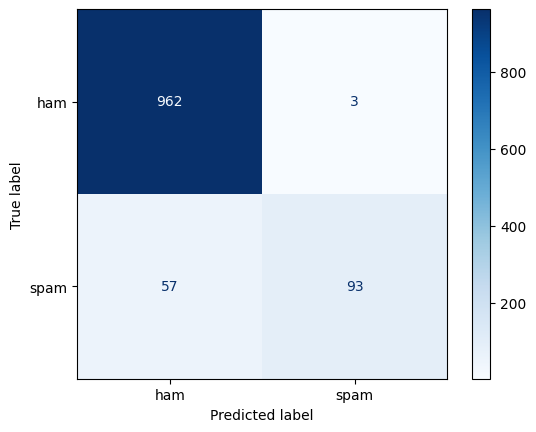

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    cmap="Blues"
)

##*PREDICT NEW SMS*

In [ ]:
sample = ["Your OTP is 789456"]

sample = vectorizer.transform(sample)

prediction = model.predict(sample)

print(prediction)

['ham']


In [ ]:
!pip install streamlit pyngrok
!npm install -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 37.9 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
added 22 packages in 2s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train_model.py to train_model.py


In [ ]:
!pip install streamlit pyngrok


In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
 streamlit run app.py

SyntaxError: invalid syntax (1291028210.py, line 1)

In [ ]:
%%writefile app.py

import streamlit as st

st.title("SMS Intent Classifier")

message = st.text_area("Enter your SMS")

if st.button("Predict"):
    st.success(f"You entered: {message}")

Overwriting app.py


In [ ]:
!streamlit run app.py --server.port 8501 &>/content/log.txt &

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3HGPhbmbFFhC3JayhXvLhPMznPk_2SHvXPBjLv8rj1UgucJik")

url = ngrok.connect(8501)
print(url)

NgrokTunnel: "https://vending-bodacious-tactical.ngrok-free.dev" -> "http://localhost:8501"
